# 3. Synthetic Populations and HDF5 I/O

If you are going to simulate the accretion of thousands of planets, using a `numpy` array is computationally vital. Additionally, `PA3Py` provides native methods to save the entire population to disk (`.h5`).

In [1]:
import sys
import os
import numpy as np
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py

# Initialize the engine
sim = PA3Py('../../tests/test_data/run_smooth_a0.001_v10')

[load_tripodpy_hdf5] Reading 100 snapshots from ../../tests/test_data/run_smooth_a0.001_v10...


## Plotting the Hovmöller Diagram

Before placing embryos, it is useful to visualize the snowlines over the disk.

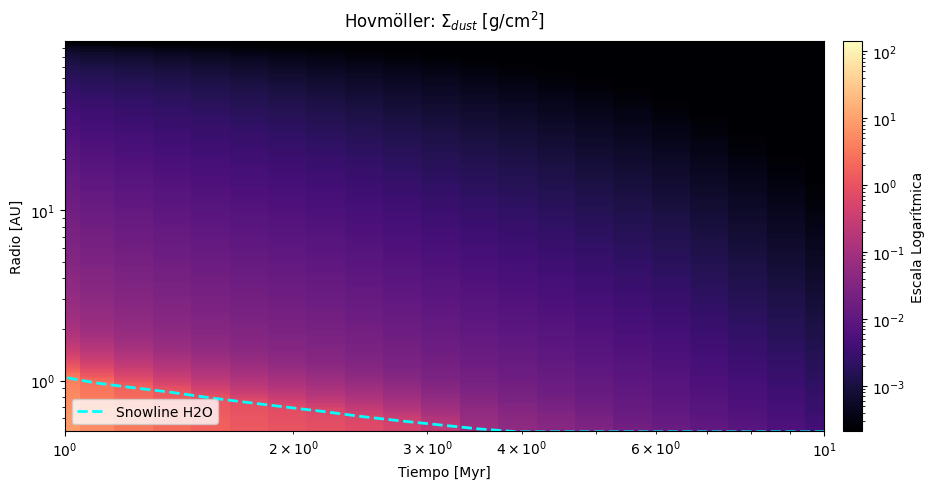

In [2]:
import matplotlib.pyplot as plt
sim.plot_hovmoller(field='dust_Sigma', show_snowlines=True)
plt.show()

## Defining the Synthetic Population

We will use `np.linspace` to generate 100 embryos along the disk.

In [3]:
# Important: to avoid infinite decimals (e.g. 1.98989), we use 99 points 
# for a range of 98 units (1 to 99) to ensure integer steps.
embryos = np.linspace(1.0, 99.0, 99).tolist()

# If you don't need to print the keys, using np.linspace(1, 99, 100) is perfectly valid.

print("Simulating", len(embryos), "embryos...")
results = sim.run_growth(embryos)

Simulating 99 embryos...



-------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]  f_silicates[%]  f_H2O[%]
-------------------------------------------------------------
    1.00        0.020         3.96            71.4      28.6
    2.00        0.164         6.65            51.8      48.2
    3.00        9.016         9.02            50.0      50.0
    4.00        0.306        11.19            50.2      49.8
    5.00        0.202        13.23            50.2      49.8
    6.00        0.177        15.16            50.3      49.7
    7.00        0.142        17.02            50.4      49.6
    8.00        0.123        18.82            50.4      49.6
    9.00        0.109        20.55            50.5      49.5
   10.00        0.099        22.24            50.5      49.5
   11.00        0.002        23.89            71.0      29.0
   12.00        0.002        25.50            82.0      18.0
   13.00        0.002        27.08            83.2      16.8
   14.00        0.001  

## Saving Results (HDF5)

We will save the entire run to the hard drive.

In [4]:
sim.save_results(results, "synthetic_population_100.h5")
print("Data saved!")

Data saved!


## Loading Results

Tomorrow, when you open this notebook again, you won't have to re-run the physics.

In [5]:
# Load the matrix and also the list of chemistry used in that run
loaded_results, chemistry = PA3Py.load_results("synthetic_population_100.h5")

print("Species from the original simulation:", chemistry)
print("Loaded planets:", len(loaded_results))

Species from the original simulation: ['silicates', 'H2O']
Loaded planets: 99
